In [393]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sn

# FASE 1: Limpieza

In [394]:
#Conexion a excel
df=pd.read_excel(r'C:\Users\USER\Desktop\Librería\@CURSOS ACTUALES\@Data Analitycs\.PYTHON 2- Librerias\@bd_collection/Inmuebles.xlsx',header=6) #recordar header permitia borrar n filas no iloc

df=df.iloc[:,:-3] 
display(df.head(10))

#Respaldo del df
df_respaldo=df.copy()

,Referencia,FechaAlta,Tip,Oper,Location,Sup M2,Precio_venta,Fventa,Vendedor,Estatus\nV = Vendida\nP = Proceso
0,1.0,2016-01-18,Estacionamiento,Alquiler,América Norte|México|Cancún,215.0,$1154980,2017-01-14,Joaquín,V
1,2.0,2016-01-20,Oficina,Alquiler,América Norte|México|Tijuana,287.0,$2851058,2017-01-02,Joaquín,V
2,3.0,2016-01-20,Local,Venta,América Norte|México|Monterrey,40.0,$321680,2017-01-11,Jesús,V
3,4.0,2016-01-24,Industrial,Venta,América Norte|México|Cancún,178.0,$1142938,2017-01-23,Joaquín,V
4,5.0,2016-02-03,Departamento,Venta,América Norte|México|Monterrey,275.0,$2141700,2017-01-08,Jesús,V
5,6.0,2016-02-07,Industrial,Alquiler,América Norte|México|Cancún,103.0,$728931,2017-02-05,Jesús,V
6,7.0,2016-02-07,Casa,Venta,América Norte|México|Ciudad de México,227.0,$1467782,2017-02-01,Carmen,V
7,8.0,2016-02-10,Departamento,Alquiler,América Norte|México|Monterrey,238.0,$1854496,2017-02-02,Luisa,V
8,9.0,2016-02-10,Departamento,Alquiler,América Norte|México|Ciudad de México,300.0,$2105700,2017-01-26,Pedro,V
9,10.0,2016-02-13,Terreno,Alquiler,América Norte|México|Tijuana,89.0,$887241,2017-01-02,Luisa,V


In [395]:
# Verificacion rapida de calidad de los datos
calidad = pd.DataFrame({
    'Duplicados':df.duplicated().mean(),
    'Nulos': df.isnull().sum(),
    'Porcentaje_nulos': df.isnull().mean() * 100,
    'Valores_unicos': df.nunique(),
    'dtypes': df.dtypes,

}) # esta presentado sobre % de las columnas

display(calidad)

#Se observa nulos en cantidad considerable para vendedor, observemos si son datos importantes o podemos eliminarlos

,Duplicados,Nulos,Porcentaje_nulos,Valores_unicos,dtypes
Referencia,0.003687,11,0.405605,2701,float64
FechaAlta,0.003687,11,0.405605,827,datetime64[us]
Tip,0.003687,11,0.405605,7,str
Oper,0.003687,11,0.405605,2,str
Location,0.003687,0,0.000000,6,str
Sup M2,0.003687,11,0.405605,261,float64
Precio_venta,0.003687,11,0.405605,2638,str
Fventa,0.003687,11,0.405605,819,datetime64[us]
Vendedor,0.003687,316,11.651917,6,str
Estatus\nV = Vendida\nP = Proceso,0.003687,11,0.405605,2,str


In [396]:
datos_Vendedor=df[df['Vendedor'].isna()].head(50)
datos_Vendedor.head(5)
#En ciertos escenarios no hay ventas de vendedor, pero si hay mas datos importantes ligadas a ello, si borramos estas filas se borraria data importante, mas si timamos en cuenta que estos representan el 11.65% de los datos.
# Otro punto que hay que tomar en cuenta, es que el VENDEDOR está ligado a la FECHA DE ALTA, por tanto al no haber FECHA DE ALTA, no hay VENDEDOR, ni FVENTA,ni ESTATUS.

#CONCLUSION: LOS DATOS SE QUEDAN pero necesitan ser manipulados

,Referencia,FechaAlta,Tip,Oper,Location,Sup M2,Precio_venta,Fventa,Vendedor,Estatus\nV = Vendida\nP = Proceso
69,NaN,NaT,NaN,NaN,||,NaN,NaN,NaT,NaN,NaN
70,NaN,NaT,NaN,NaN,||,NaN,NaN,NaT,NaN,NaN
71,NaN,NaT,NaN,NaN,||,NaN,NaN,NaT,NaN,NaN
72,NaN,NaT,NaN,NaN,||,NaN,NaN,NaT,NaN,NaN
77,NaN,NaT,NaN,NaN,||,NaN,NaN,NaT,NaN,NaN


In [397]:
data_nula=df[df['Referencia'].isna()]
print('La cantidad de data nula es: ',data_nula.size)
#Las demás columnas del df si tiene ciertos datos nulos que se repiten a ambas, parece haber datos faltantes en toda la fila, por tanto tiene sentido que borremos estos datos

data_nula.head(5)
df=df.dropna(subset='Referencia')
df.head(5)

#Comprobemos con calidad otra vez si los datos ahora estan limpios, veamos si los datos presentan tipo de datos coherentes respecto  del tipo de informacion que buscan representar

La cantidad de data nula es:  110


,Referencia,FechaAlta,Tip,Oper,Location,Sup M2,Precio_venta,Fventa,Vendedor,Estatus\nV = Vendida\nP = Proceso
0,1.0,2016-01-18,Estacionamiento,Alquiler,América Norte|México|Cancún,215.0,$1154980,2017-01-14,Joaquín,V
1,2.0,2016-01-20,Oficina,Alquiler,América Norte|México|Tijuana,287.0,$2851058,2017-01-02,Joaquín,V
2,3.0,2016-01-20,Local,Venta,América Norte|México|Monterrey,40.0,$321680,2017-01-11,Jesús,V
3,4.0,2016-01-24,Industrial,Venta,América Norte|México|Cancún,178.0,$1142938,2017-01-23,Joaquín,V
4,5.0,2016-02-03,Departamento,Venta,América Norte|México|Monterrey,275.0,$2141700,2017-01-08,Jesús,V


In [398]:
calidad = pd.DataFrame({
    'Duplicados':df.duplicated().mean(),
    'Nulos': df.isnull().sum(),
    'Porcentaje_nulos': df.isnull().mean() * 100,
    'Valores_unicos': df.nunique(),
    'dtypes': df.dtypes,

}) # esta presentado sobre % de las columnas

display(calidad)

,Duplicados,Nulos,Porcentaje_nulos,Valores_unicos,dtypes
Referencia,0.0,0,0.000000,2701,float64
FechaAlta,0.0,0,0.000000,827,datetime64[us]
Tip,0.0,0,0.000000,7,str
Oper,0.0,0,0.000000,2,str
Location,0.0,0,0.000000,5,str
Sup M2,0.0,0,0.000000,261,float64
Precio_venta,0.0,0,0.000000,2638,str
Fventa,0.0,0,0.000000,819,datetime64[us]
Vendedor,0.0,305,11.292114,6,str
Estatus\nV = Vendida\nP = Proceso,0.0,0,0.000000,2,str


Tenemos Str en 'Precio_venta y Estatus\nV = Vendida\nP = Proceso' , el nombre que no es intuitivo, 

Renombremos los nombres de las columnas y corrigamos los tipos de datos de las columas del df

In [399]:
#No confiarse de lo que se ve en las columnas, aveces falla y casi siempre es por esto
list(df.columns)

['Referencia',
 'FechaAlta',
 'Tip',
 'Oper',
 'Location',
 'Sup M2',
 'Precio_venta',
 'Fventa',
 'Vendedor',
 'Estatus\nV = Vendida\nP = Proceso']

Recordaris clave, en pandas no trabajas como si fueran datos, se trabaja con lo que se llama accesores, que es lo que usa pandas para referirse a trabajar sobre toda una columna. Recordar usar '.str', '.dt', '.numeric'  , al querer TRABAJAR sobre toda la COLUMNA de un DATAFRAME

In [400]:
# df = df['Precio_venta'].str.strip().str.replace('$','') # <--- Cuidado estas conviertiendo tu df en una serie al igualarla a 'Precio_Venta'
df['Precio_venta']=df['Precio_venta'].str.strip().str.replace('$','').astype(int)
df.head(2)

,Referencia,FechaAlta,Tip,Oper,Location,Sup M2,Precio_venta,Fventa,Vendedor,Estatus\nV = Vendida\nP = Proceso
0,1.0,2016-01-18,Estacionamiento,Alquiler,América Norte|México|Cancún,215.0,1154980,2017-01-14,Joaquín,V
1,2.0,2016-01-20,Oficina,Alquiler,América Norte|México|Tijuana,287.0,2851058,2017-01-02,Joaquín,V


In [401]:
# pos = df.columns.get_loc('Location')
# split = df.pop('Location').str.split('|', expand=True)
# split.columns = ['Continente','Pais','Ciudad']

# df = pd.concat([df.iloc[:, :pos], split, df.iloc[:, pos:]], axis=1)
# df

In [402]:
#Dividir la colunba unida en 3 columnas nuevas
df[['Continente','Pais','Ciudad']]=df['Location'].str.split('|',expand=True)
df.head(3)

#Borramos la columna original
df=df.drop('Location',axis=1)
df.head(3)

,Referencia,FechaAlta,Tip,Oper,Sup M2,Precio_venta,Fventa,Vendedor,Estatus\nV = Vendida\nP = Proceso,Continente,Pais,Ciudad
0,1.0,2016-01-18,Estacionamiento,Alquiler,215.0,1154980,2017-01-14,Joaquín,V,América Norte,México,Cancún
1,2.0,2016-01-20,Oficina,Alquiler,287.0,2851058,2017-01-02,Joaquín,V,América Norte,México,Tijuana
2,3.0,2016-01-20,Local,Venta,40.0,321680,2017-01-11,Jesús,V,América Norte,México,Monterrey


In [403]:
#Remplazo de V y P por Vendido y Proceso
display(df['Estatus\nV = Vendida\nP = Proceso'].value_counts())
df['Estatus\nV = Vendida\nP = Proceso']=df['Estatus\nV = Vendida\nP = Proceso'].replace(
    {
       'V':'Vendido',
       'P':'Proceso' 
    }
)

Estatus\nV = Vendida\nP = Proceso
V    2396
P     305
Name: count, dtype: int64

In [404]:
#Renombrado columnas
df=df.rename(columns=
          {
            'Referencia':'Codigo referencia',
            'FechaAlta':'Fecha de alta operacion',
            'Tip':'Tipo Inmueble',
            'Oper': 'Tipo de operacion',
            'Sup M2':'Superficie - M2',
            'Precio_venta':'Precio de venta',
            'Fventa': 'Fecha de venta',
            'Estatus\nV = Vendida\nP = Proceso':'Estatus operacion'
          }
          )

In [405]:
calidad = pd.DataFrame({
    'Duplicados':df.duplicated().mean(),
    'Nulos': df.isnull().sum(),
    'Porcentaje_nulos': df.isnull().mean() * 100,
    'Valores_unicos': df.nunique(),
    'dtypes': df.dtypes,

}) # esta presentado sobre % de las columnas

display(calidad)

,Duplicados,Nulos,Porcentaje_nulos,Valores_unicos,dtypes
Codigo referencia,0.0,0,0.000000,2701,float64
Fecha de alta operacion,0.0,0,0.000000,827,datetime64[us]
Tipo Inmueble,0.0,0,0.000000,7,str
Tipo de operacion,0.0,0,0.000000,2,str
Superficie - M2,0.0,0,0.000000,261,float64
Precio de venta,0.0,0,0.000000,2638,int64
Fecha de venta,0.0,0,0.000000,819,datetime64[us]
Vendedor,0.0,305,11.292114,6,str
Estatus operacion,0.0,0,0.000000,2,str
Continente,0.0,0,0.000000,1,str


Aseguremonos de pasar todo los datos de vendedor nulos que teniamos, a datos tangibles.  Los nulos al momento de intentar aplicar un modelo de Machine Learning podria generar errores o incluso al trabajar con los datos en EDA. Cambiemos los datos de nulos a algo tipo "Sin vendedor aun".

De momento tenemos:
- Ya liberamos todos los nulos
- Limpiamos columnas con simbolos de dolar
- Separamos columnas que estaban juntas
- Nos aseguramos de que las columnas tenga un dtype correcto
- Renombramos a las columnas con titulos adecuados

In [406]:
df['Vendedor']=df['Vendedor'].fillna('Sin vendedor')


In [407]:
calidad = pd.DataFrame({
    'Duplicados':df.duplicated().mean(),
    'Nulos': df.isnull().sum(),
    'Porcentaje_nulos': df.isnull().mean() * 100,
    'Valores_unicos': df.nunique(),
    'dtypes': df.dtypes,

}) # esta presentado sobre % de las columnas

display(calidad)

,Duplicados,Nulos,Porcentaje_nulos,Valores_unicos,dtypes
Codigo referencia,0.0,0,0.0,2701,float64
Fecha de alta operacion,0.0,0,0.0,827,datetime64[us]
Tipo Inmueble,0.0,0,0.0,7,str
Tipo de operacion,0.0,0,0.0,2,str
Superficie - M2,0.0,0,0.0,261,float64
Precio de venta,0.0,0,0.0,2638,int64
Fecha de venta,0.0,0,0.0,819,datetime64[us]
Vendedor,0.0,0,0.0,7,str
Estatus operacion,0.0,0,0.0,2,str
Continente,0.0,0,0.0,1,str


# FASE 2: Exploracion visual

In [408]:
df.head(5)
df_copy=df.copy()

,Ciudad,Codigo referencia,Fecha de alta operacion,Tipo Inmueble,Tipo de operacion,Superficie - M2,Precio de venta,Fecha de venta,Vendedor,Estatus operacion,Continente,Pais
2,Monterrey,680,680,680,680,680,680,680,680,680,680,680
0,Cancún,670,670,670,670,670,670,670,670,670,670,670


([0, 1, 2, 3, 4],
 [Text(0, 0, 'Monterrey'),
  Text(1, 0, 'Cancún'),
  Text(2, 0, 'Tijuana'),
  Text(3, 0, 'Ciudad de México'),
  Text(4, 0, 'New York')])

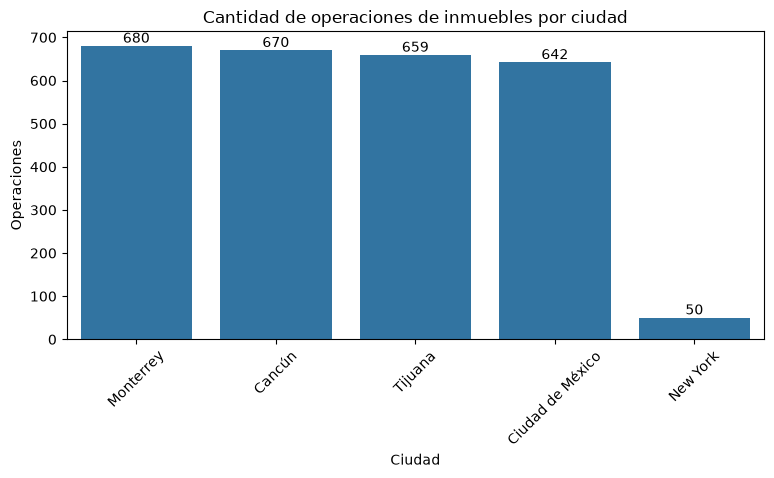

In [409]:
#Groupby para agrupar operaciones por ciudad
conteo=df.groupby('Ciudad').count().reset_index().sort_values(by='Vendedor',ascending=False)
display(conteo.head(2))

plt.figure(figsize=(9,4))
ax=sn.barplot(data=conteo, x='Ciudad',y='Codigo referencia') #Aplicar sn.barplot a ax
for container in ax.containers:#Aplicar labels a ax.container
    ax.bar_label(container)
    
plt.title('Cantidad de operaciones de inmuebles por ciudad')
plt.xlabel('Ciudad')
plt.ylabel('Operaciones')
plt.xticks(rotation=45)


,Ciudad,Codigo referencia,Fecha de alta operacion,Tipo Inmueble,Tipo de operacion,Superficie - M2,Precio de venta,Fecha de venta,Vendedor,Estatus operacion,Continente,Pais
3,New York,50,50,50,50,50,50,50,50,50,50,50
1,Ciudad de México,642,642,642,642,642,642,642,642,642,642,642


([0, 1, 2, 3, 4],
 [Text(0, 0, 'Cancún'),
  Text(1, 0, 'Tijuana'),
  Text(2, 0, 'Monterrey'),
  Text(3, 0, 'Ciudad de México'),
  Text(4, 0, 'New York')])

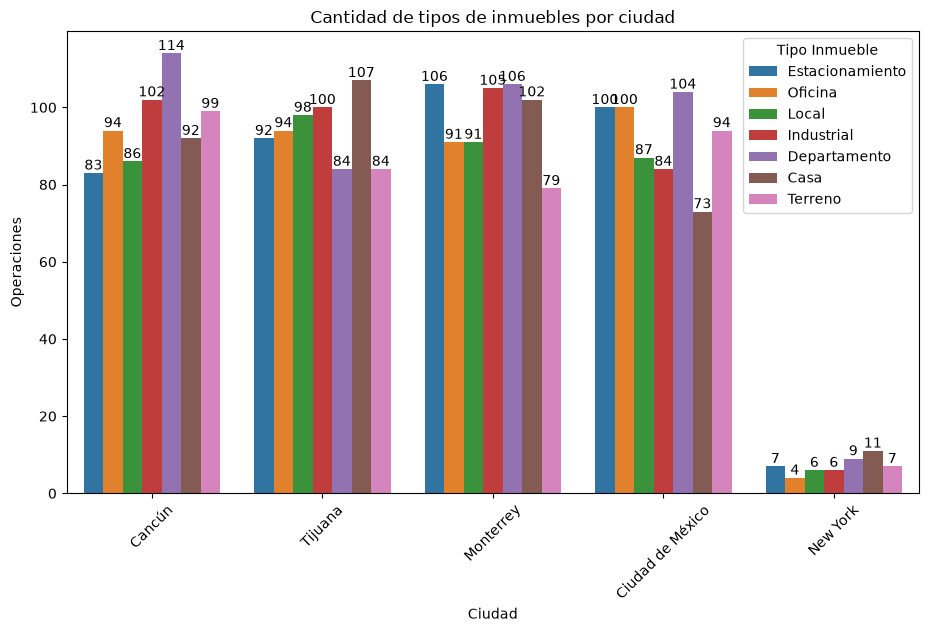

In [410]:
#Groupby para agrupar Tipo de inmuebles por ciudad
conteo=df.groupby('Ciudad').count().reset_index().sort_values(by='Vendedor',ascending=True)
display(conteo.head(2))

plt.figure(figsize=(11,6))
ax=sn.countplot(data=df, x='Ciudad',hue='Tipo Inmueble')
for container in ax.containers: #Aplicar bar_label a cada container
    ax.bar_label(container)
    
plt.title('Cantidad de tipos de inmuebles por ciudad')
plt.xlabel('Ciudad')
plt.ylabel('Operaciones')
plt.xticks(rotation=45)


In [411]:
#Groupby para agrupar Tipo de inmuebles por ciudad
ops_ciudad=df.groupby(['Ciudad','Tipo Inmueble']).size().reset_index().head(5) #Todos los datos
display(ops_ciudad)

#O Tabla cruzada para contar por ciudad
table_pivot=pd.crosstab(df['Ciudad'],df['Tipo Inmueble']) #Contado y cruzado por ciudad
table_pivot

,Ciudad,Tipo Inmueble,0
0,Cancún,Casa,92
1,Cancún,Departamento,114
2,Cancún,Estacionamiento,83
3,Cancún,Industrial,102
4,Cancún,Local,86


Tipo Inmueble,Casa,Departamento,Estacionamiento,Industrial,Local,Oficina,Terreno
Ciudad,,,,,,,
Cancún,92,114,83,102,86,94,99
Ciudad de México,73,104,100,84,87,100,94
Monterrey,102,106,106,105,91,91,79
New York,11,9,7,6,6,4,7
Tijuana,107,84,92,100,98,94,84


(array([0, 1, 2, 3, 4]),
 [Text(0, 0, 'Cancún'),
  Text(1, 0, 'Ciudad de México'),
  Text(2, 0, 'Monterrey'),
  Text(3, 0, 'New York'),
  Text(4, 0, 'Tijuana')])

<Figure size 1200x900 with 0 Axes>

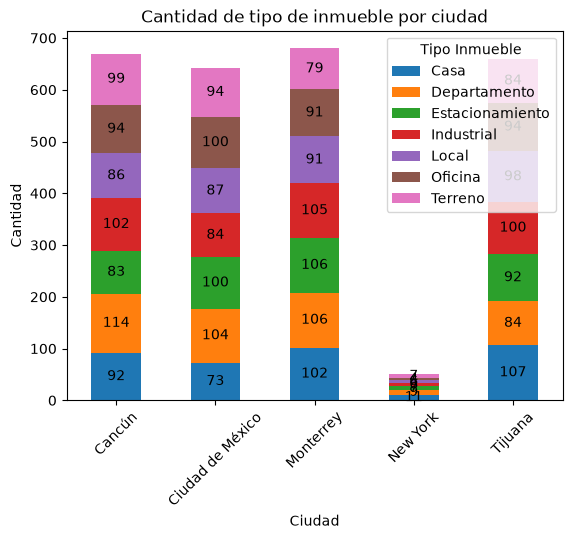

In [412]:
#Grafico de barras apilado: Tipo de inmuebles por ciudad
plt.figure(figsize=(12,9))

ax=table_pivot.plot(kind='bar',stacked=True)
for container in ax.containers:
    ax.bar_label(container,fontsize=10,label_type='center')

plt.title('Cantidad de tipo de inmueble por ciudad')
plt.xlabel('Ciudad')
plt.ylabel('Cantidad')
plt.xticks(rotation=45)

In [413]:
#Grafico de tipo de inmuebles por ciudad en %______________________

total_ciudad=table_pivot.sum(axis=1)
display(total_ciudad) #Sumamos cuanto hay por cada ciudad

div_por_ciudad=table_pivot.div(total_ciudad,axis=0)*100
div_por_ciudad #Dividimos nuestra tabla entre el total de cada ciudad

Ciudad
Cancún              670
Ciudad de México    642
Monterrey           680
New York             50
Tijuana             659
dtype: int64

Tipo Inmueble,Casa,Departamento,Estacionamiento,Industrial,Local,Oficina,Terreno
Ciudad,,,,,,,
Cancún,13.731343,17.014925,12.388060,15.223881,12.835821,14.029851,14.776119
Ciudad de México,11.370717,16.199377,15.576324,13.084112,13.551402,15.576324,14.641745
Monterrey,15.000000,15.588235,15.588235,15.441176,13.382353,13.382353,11.617647
New York,22.000000,18.000000,14.000000,12.000000,12.000000,8.000000,14.000000
Tijuana,16.236722,12.746586,13.960546,15.174507,14.871017,14.264036,12.746586


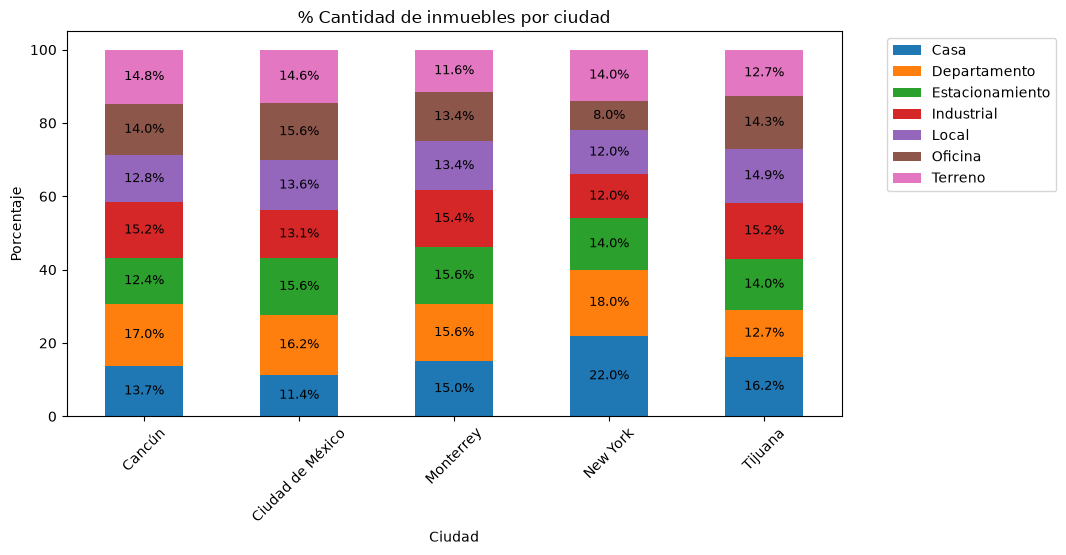

In [414]:

ax=div_por_ciudad.plot(kind='bar',stacked=True,figsize=(10,5))
for container in ax.containers:
    ax.bar_label(container,labels=[f'{v:.1f}%' for v in container.datavalues],label_type='center',fontsize=9) 

plt.title('% Cantidad de inmuebles por ciudad')
plt.xlabel('Ciudad')
plt.ylabel('Porcentaje')
plt.xticks(rotation=45)
ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left')


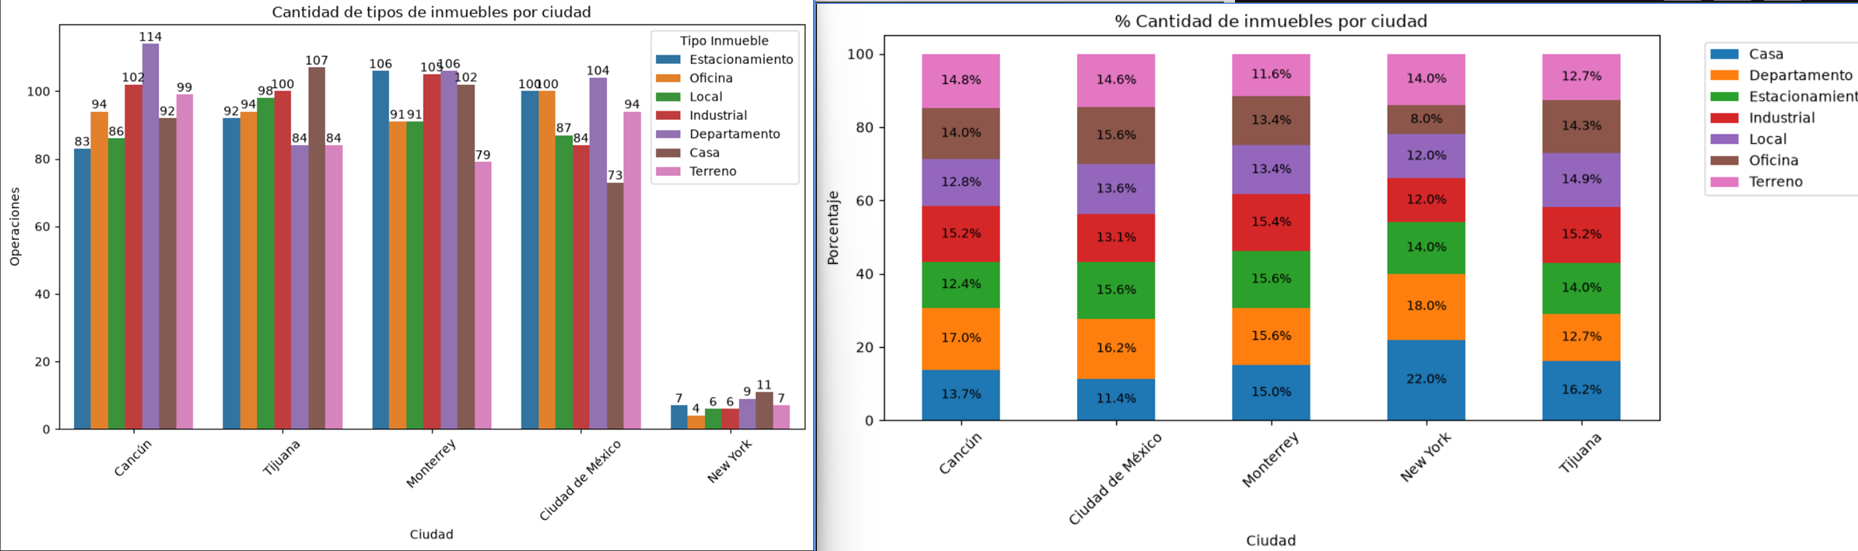

In [415]:
from IPython.display import Image, display
ruta_archivo = r"C:\Users\USER\Documents\ShareX\Screenshots\2026-06\28d=07.58 hrs''20s-PM.png"
display(Image(filename=ruta_archivo))



#### CONCLUSIONES

#### Podemos visualizar que porcentaje  de inmuebles por ciudad es muy parecido, por lo que no se pude concluir que algun tipo de operacion sea dominante. Por tanto que ver que tipo de operacion es la que es mas lucrativa, de paso podriamos ver cual es la menos lucrativa tambien.

#### Tambien se puede visualizar que en New York hay menos cantidad de operaciones, tendriamos que averiguar tambien porque pasa eso.

# FASE3: Aplicando Machine learning

In [416]:
# PAQUETE LIBRERIAS ANALISIS DE DATOS y de SKLEARN


from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import OrdinalEncoder
from sklearn.preprocessing import StandardScaler

from sklearn.model_selection import train_test_split as tts
from sklearn.model_selection import cross_val_score

from sklearn.metrics import r2_score
from sklearn.metrics import mean_absolute_error, mean_squared_error


from sklearn.linear_model import LinearRegression




    PASOS para construir un modelo de Machine Learning 

    1.Definir x e y | iloc,loc, concat,etc
    2.Definir split | definit tts
    3.Definir preprocesamiento | Columntrasnform
    4.Definir Pipeline
    5.Cross validation sobre train ('x,y'test)
    6.Fit('x,y' train) y predict('x'train,'x'test) del pipeline
    7.Evaluar las metricas de error | r2 (test,train),MSE,RMSE, MAPE
    8.Graficacion visual del modelo y exploracion de residuos y MAPE
    9.Transformacion del target con logaritmo
    10.11.Probar otro modelo
    10.11.Probar nuevas variables dependientes

In [417]:
df.head(5)
#OBJETIVO: Predecir el precio de venta en base a las demas columnas 

# 0) Para defeinir que variables son predictoras de la variable independiente, tocara hacernos la pregunta si cada una de las columnas podria influir en el precio de venta.

    # ['Codigo referencia', No, es un solo codigo
    #  'Fecha de alta operacion', No, indica una fecha donde el tipo de operacion finalizó
    #  'Tipo Inmueble', SI, indica que tipo de inmueble es
    #  'Tipo de operacion', SI, Indica el tipo de la operacion
    #  'Superficie - M2', SI, mas tamaño cualquier inmueble cuesta mas
    #  'Precio de venta', SI, Variable target Y
    #  'Fecha de venta', # Podria servir para otro target u otra variable
    #  'Vendedor', #No influye
    #  'Estatus operacion', # Es mas informativo
    #  'Continente', # Talvez podria influir, aunque quiza en menor medida
    #  'Pais', # Talvez, un pais maneja diferentes monedas y diferentes costos de vida y nivel adquisitivo
    # 'Ciudad'] # SI, pero Ciudad seria el mas preciso de los datos de ubicacion, por tanto deberíamos considerarlo mas importante para no introducir variables que midan lo mismo( prediccion de precio en base a ubicacion)

# La eleccion debería ser planteada por todo el equipo, o conociendo los datos del negocio , estas solo serian pruebas para el modelo por parte del analista y no deberia sustutir una opinion de alguien del rubro inmobiliario o que conoce acerca de él.

,Codigo referencia,Fecha de alta operacion,Tipo Inmueble,Tipo de operacion,Superficie - M2,Precio de venta,Fecha de venta,Vendedor,Estatus operacion,Continente,Pais,Ciudad
0,1.0,2016-01-18,Estacionamiento,Alquiler,215.0,1154980,2017-01-14,Joaquín,Vendido,América Norte,México,Cancún
1,2.0,2016-01-20,Oficina,Alquiler,287.0,2851058,2017-01-02,Joaquín,Vendido,América Norte,México,Tijuana
2,3.0,2016-01-20,Local,Venta,40.0,321680,2017-01-11,Jesús,Vendido,América Norte,México,Monterrey
3,4.0,2016-01-24,Industrial,Venta,178.0,1142938,2017-01-23,Joaquín,Vendido,América Norte,México,Cancún
4,5.0,2016-02-03,Departamento,Venta,275.0,2141700,2017-01-08,Jesús,Vendido,América Norte,México,Monterrey


In [418]:
# 1. VARIABLES
# x = variables que explican el precio
# y = variable objetivo (lo que buscamos predecir con nuestro modelo)
x = df[['Tipo Inmueble', 'Ciudad', 'Superficie - M2']]
y = df['Precio de venta']

# 2. SPLIT TRAIN 
X_train, X_test, y_train, y_test = tts(
    x,
    y,
    test_size=0.20,
    random_state=42  # asegura reproducibilidad del modelo
)

# 3. PREPROCESAMIENTO  con ColumnTransformer
preprocessor = ColumnTransformer([
    ( 'OHE',OneHotEncoder(handle_unknown='ignore'),['Tipo Inmueble', 'Ciudad']    ),
    ( 'Scaler', StandardScaler(), ['Superficie - M2']    )
])

# 4. PIPELINE (MUY IMPORTANTE)
pipeline = Pipeline([
    ('prep', preprocessor),
    ('model', LinearRegression())
])

# 5. CROSS VALIDATION (SOLO TRAIN)
# IMPORTANTe: Lo usamos para que el train y split no cometa errores de asignar datos de forma aleatoria y obtener evaluaciones en base a esta asignacion, con cross Value nos aseguraos de aplicar almenos 5 folds  y obtener metricas en base a estos 5 folds para evaluar train
cv_scores = cross_val_score(
    pipeline,
    X_train,
    y_train,
    cv=5,
    scoring='r2'
)

print("========== CROSS VALIDATION ==========")
print("R² por fold:", cv_scores)
print("R² promedio CV:", cv_scores.mean())
print("Desviación estándar CV:", cv_scores.std())

========== CROSS VALIDATION ==========
R² por fold: [0.73852458 0.74461328 0.7001637  0.74171549 0.72934649]
R² promedio CV: 0.7308727070259058
Desviación estándar CV: 0.016188221332900096


In [419]:
# 6 y 7. ENTRENAMIENTO FINAL, PREDICCIONES Y EVALUACION DEL MODELO
pipeline.fit(X_train, y_train) #fit sobre training

y_pred_train= pipeline.predict(X_train)
y_pred_test=pipeline.predict(X_test)

# 6. METRICAS DE EVALAUCION DEL MODEO
r2_train= r2_score(y_train, y_pred_train)
print('r2_score_train:',np.round(r2_train, 2))
r2_test= r2_score(y_test, y_pred_test)
print('r2_score_test:',np.round(r2_test, 2),'\n')

mae= mean_absolute_error(y_test, y_pred_test)
print('MAE| mean_absolute_error: ',np.round(mae, 2))
mae_percent= (mae / y_test.mean()) * 100
print('MAE %| mean_absolute_error %:',np.round(mae_percent, 2),'\n')


rmse= np.sqrt(mean_squared_error(y_test, y_pred_test))
print('RMSE| mean_squared_error: ',np.round(rmse, 2))
rmse_percent= rmse/y_test.mean()*100
print('RMSE %| mean_squared_error %:',np.round(rmse_percent, 2),'\n')

mape = np.round(np.mean(np.abs((y_test - y_pred_test) / y_test) * 100),2) #No olvidar el denominador debe ser el valor real, no el predicho, ya que queremos saber cuanto nos equivocamos respecto al valor real
print('MAPE: ',mape,'%')



#MAE/RMSE en % → primero obtienen un número en dólares, luego tú lo divides entre y_test.mean() (promedio global)
#MAPE → divide cada error entre su y_test individual, luego promedia esos porcentajes

r2_score_train: 0.74
r2_score_test: 0.72 

MAE| mean_absolute_error:  264547.19
MAE %| mean_absolute_error %: 21.7 

RMSE| mean_squared_error:  335122.75
RMSE %| mean_squared_error %: 27.49 

MAPE:  23.87 %


### 7.1) Interpretación de métricas

#### Coeficiente de determinación (R²)

 R² Test: 0.75
El modelo explica aproximadamente el 75 % de la variabilidad del precio de las viviendas utilizando:
  - Tipo de inmueble.
  - Ciudad.
  - Superficie.

#### ¿Existe overfitting?

Diferencia entre entrenamiento y prueba:

```text
R² Train - R² Test = 0.013
```

| Diferencia | Interpretación |
|------------|----------------|
| < 0.03 | Excelente |
| 0.03 - 0.07 | Aceptable |
| 0.07 - 0.15 | Revisar |
| > 0.15 | Overfitting claro |

Como la diferencia es 0.013, el modelo no presenta overfitting y logra generalizar adecuadamente sobre datos no vistos.

#### Consistencia mediante Validación Cruzada

- R² por fold

```text
[0.7385, 0.7446, 0.7002, 0.7417, 0.7293]
```

- R² promedio: 0.7309
- Desviación estándar: 0.0162

Los valores obtenidos en cada fold son muy similares entre sí y presentan una baja variabilidad, lo que indica que el rendimiento del modelo es estable y no depende excesivamente de una partición específica de los datos.

---

#### ¿Será consistente en la vida real?

Los resultados obtenidos sugieren que sí existe una buena capacidad de generalización, ya que:

- La diferencia entre R² Train y R² Test es muy pequeña.
- La validación cruzada obtuvo resultados consistentes.
- La variabilidad entre folds es baja.

Sin embargo, este desempeño solo puede garantizarse para datos provenientes de una distribución similar a la utilizada durante el entrenamiento. Viviendas con características muy distintas o que usan variables predictoras diferentes a las usadas en el modelo o en su defecto usan mas(como es muy probable en un entorno real), es muy probable que el modelo decaiga muchisimo en capacidad predictora

---

#### Error Absoluto Medio (MAE)

- MAE: 264 547.19

En promedio, la predicción del modelo se desvía aproximadamente  264 547 del precio real de una vivienda.

Este error representa aproximadamente el 21.7 % del precio promedio de las viviendas del conjunto de datos.

---

#### Raíz del Error Cuadrático Medio (RMSE)

- RMSE: 335 122.75

Cuando existen errores grandes, el modelo presenta un error promedio cercano a  335 123, equivalente aproximadamente al 27.49 % del precio promedio.

Como el RMSE es considerablemente mayor que el MAE, esto indica la presencia de algunas viviendas con errores de predicción elevados (outliers).

---

#### MAPE(): 23.87 %

En promedio, las predicciones del modelo se desvían un 23.87 % del precio real de cada vivienda,
independientemente de si sobreestima o subestima.

A diferencia del MAE y RMSE, cuyo resultado natural son las unidades del target (dólares),
el MAPE entrega directamente un porcentaje, lo que facilita interpretar el error
sin necesidad de contexto adicional sobre la escala de los precios.
|

    Error porcentual promedio	Interpretación
    5%	                        Excelente
    5% – 10%	                Muy bueno
    10% – 20%	                Bueno
    20% – 30%	                Aceptable
    30%	                        Mejorable

### 7.2) Conclusiones

- ✅ El modelo explica aproximadamente el 75 % de la variabilidad del precio de las viviendas.
- ✅ La diferencia entre R² Train y R² Test (0.013) indica una excelente capacidad de generalización y ausencia de overfitting.
- ✅ La validación cruzada muestra resultados consistentes, con una desviación estándar baja (0.0162), lo que evidencia un modelo estable.
- ⚠️ El RMSE es mayor que el MAE, lo que evidencia la existencia natural de errores grandes debido a valores atipicos.


#### 
    Overfitting                   No.
    Underfitting severo           No.
    Modelo estable                Sí.

### 8.Graficacion visual del modelo y exploracion de residuos y MAPE

#### 8.1.Residuos y MAPE

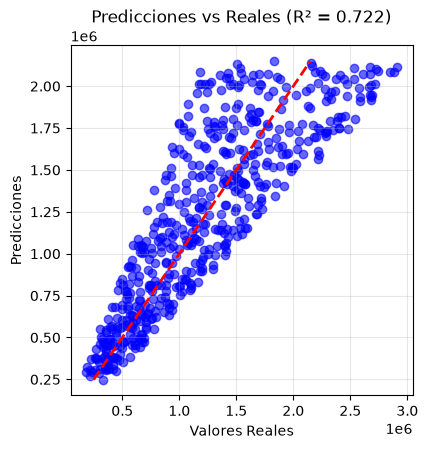

In [420]:
plt.figure(figsize=(15, 10))

# 1. Predicciones vs Valores reales
plt.subplot(2, 3, 1)
plt.scatter(y_test, y_pred_test, alpha=0.6, color='blue')
plt.plot([y_pred_test.min(), y_pred_test.max()],
         [y_pred_test.min(), y_pred_test.max()], 'r--', lw=2) 
plt.xlabel('Valores Reales')
plt.ylabel('Predicciones')
plt.title(f'Predicciones vs Reales (R² = {r2_test:.3f})') 
plt.grid(True, alpha=0.3)
plt.show()

In [421]:
display("Residuos (y_test - y_pred_test):", (y_test - y_pred_test).head(5))

error_pct = np.mean(((y_test - y_pred_test) / y_test) * 100)
print( "Error porcentual promedio(promedio del diferencia de ytest - ypred):", round(error_pct, 2),"%")
    # positivo → el modelo subestimó
    # negativo → el modelo sobreestimó


'Residuos (y_test - y_pred_test):'

2061     47164.158283
1145   -601130.536878
1568   -133254.133766
343    -420774.100210
1440    178415.605215
Name: Precio de venta, dtype: float64

Error porcentual promedio(promedio del diferencia de ytest - ypred): -6.91 %


#El error porcentual al ser un promedio de todos los residuos, puede ser tanto negativo como positivo y se interperta tal cual los residuos. Pero lo hace en base a cuanto + o - cuanto porcentaje se equivoca en promedio nuestro modelo.

- en nuestro modelo  es del **- 6.91%**, Significa que el modelo sobreestima en promedio el target(y) un 6.91%.
- Mientras que si el error porcentual fuera **+ 6.91%** , significaria que  el modelo subestima en promedio el target(y) un 6.91%

RESUMEN DE LA EVALUACION: Esto confirma que hay algunos errores grandes, pero no en una magnitud alarmante, en modelos de ML para viviendas es un numero esperable



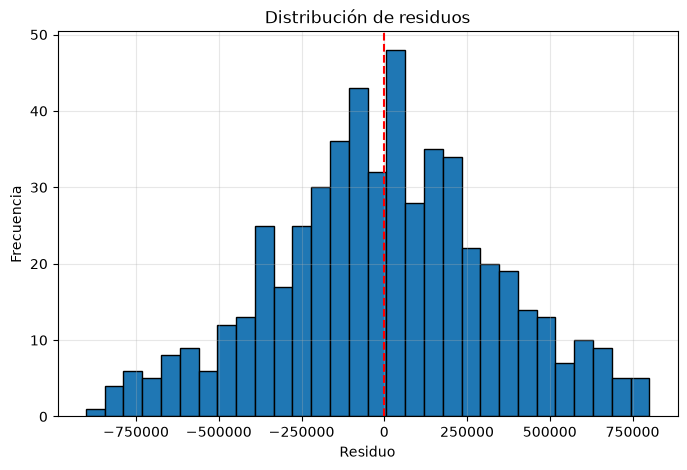

In [422]:
residuos = y_test - y_pred_test
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
plt.hist(residuos, bins=30, edgecolor='black')
plt.axvline(0, color='red', linestyle='--')
plt.xlabel('Residuo')
plt.ylabel('Frecuencia')
plt.title('Distribución de residuos')
plt.grid(alpha=0.3)
plt.show()

### 8.2. Exploracion individual de los residuos

In [423]:
residuos_abs = (y_test - y_pred_test).head(10).abs()
top_errores = residuos_abs.sort_values(ascending=False).head(10)
print(top_errores)

1145    601130.536878
2467    495776.007630
343     420774.100210
88      409779.445948
900     219873.222218
1440    178415.605215
1568    133254.133766
2061     47164.158283
1236     33466.951866
2302     24273.045170
Name: Precio de venta, dtype: float64


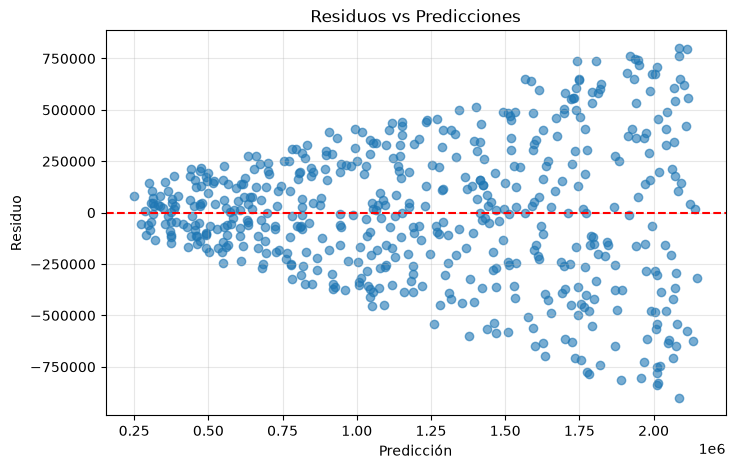

In [424]:
plt.figure(figsize=(8, 5))
plt.scatter(y_pred_test, residuos, alpha=0.6)
plt.axhline(0, color='red', linestyle='--')
plt.xlabel('Predicción')
plt.ylabel('Residuo')
plt.title('Residuos vs Predicciones')
plt.grid(alpha=0.3)
plt.show()


Ideal

    Distribución aproximadamente simétrica.
    Centrada en cero.
    Sin sesgo evidente.

Tendremos probmeas potenciales cuando:

    Desplazada a la izquierda o derecha.
    Cola muy larga.
    Varios valores extremos.

## ---Interpretación Residuos vs Predicciones
Buen comportamiento

    Los puntos se distribuyen aleatoriamente alrededor de cero.

Patrón de abanico

    La dispersión aumenta para valores altos, indicando heterocedasticidad.

Curvatura

    Sugiere relaciones no lineales.


 ### Diagnóstico principal: heterocedasticidad

forma de abanico:

    Para predicciones bajas, los residuos son relativamente pequeños.
    Para predicciones altas, la dispersión crece considerablemente.
    Esto se conoce como heterocedasticidad.

Significado

    A medida que el precio predicho aumenta, también aumenta la incertidumbre del modelo.
    En propiedades caras es normal tener errores absolutos mucho mayores.



In [425]:
df_copy

,Codigo referencia,Fecha de alta operacion,Tipo Inmueble,Tipo de operacion,Superficie - M2,Precio de venta,Fecha de venta,Vendedor,Estatus operacion,Continente,Pais,Ciudad
0,1.0,2016-01-18,Estacionamiento,Alquiler,215.0,1154980,2017-01-14,Joaquín,Vendido,América Norte,México,Cancún
1,2.0,2016-01-20,Oficina,Alquiler,287.0,2851058,2017-01-02,Joaquín,Vendido,América Norte,México,Tijuana
2,3.0,2016-01-20,Local,Venta,40.0,321680,2017-01-11,Jesús,Vendido,América Norte,México,Monterrey
3,4.0,2016-01-24,Industrial,Venta,178.0,1142938,2017-01-23,Joaquín,Vendido,América Norte,México,Cancún
4,5.0,2016-02-03,Departamento,Venta,275.0,2141700,2017-01-08,Jesús,Vendido,América Norte,México,Monterrey
...,...,...,...,...,...,...,...,...,...,...,...,...
2707,2697.0,2018-12-30,Industrial,Alquiler,149.0,667520,2019-03-30,Sin vendedor,Proceso,América Norte,Estados Unidos,New York
2708,2698.0,2018-12-30,Casa,Alquiler,264.0,1060488,2019-04-28,Joaquín,Vendido,América Norte,Estados Unidos,New York
2709,2699.0,2018-12-31,Oficina,Venta,69.0,483828,2019-05-05,Pedro,Vendido,América Norte,Estados Unidos,New York
2710,2700.0,2018-12-31,Departamento,Alquiler,64.0,478272,2019-03-31,Sin vendedor,Proceso,América Norte,Estados Unidos,New York


### 9.Transformacion de target con logaritmo


In [426]:
# ==========================================
# MODELO DE REGRESIÓN CON TARGET EN LOG 
# ==========================================

import numpy as np
from sklearn.model_selection import train_test_split as tts, cross_val_score
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error


# ==========================================
# 1. VARIABLES (FEATURES Y TARGET)
# ==========================================
# Features (X)
X = df_copy[['Tipo Inmueble', 'Ciudad', 'Superficie - M2', 'Tipo de operacion', 'Pais']]

# Target en logaritmo
# ✔️ Reduce impacto de outliers
# ❗ El modelo aprende log(precio), no precio real
y = np.log(df['Precio de venta'])


# ==========================================
# 2. TRAIN / TEST SPLIT
# ==========================================
# ✔️ Holdout final para evaluación real
X_train, X_test, y_train, y_test = tts(
    X, y,
    test_size=0.20,
    random_state=42
)


# ==========================================
# 3. PREPROCESAMIENTO
# ==========================================
# ✔️ Convierte categóricas a numéricas + escala numéricas
preprocessor = ColumnTransformer([
    ('OHE', OneHotEncoder(handle_unknown='ignore'),
     ['Tipo Inmueble', 'Ciudad', 'Tipo de operacion', 'Pais']),

    ('Scaler', StandardScaler(),
     ['Superficie - M2'])
])




In [427]:
# ==========================================
# 4. PIPELINE
# ==========================================
# ✔️ Evita data leakage
pipeline = Pipeline([
    ('prep', preprocessor),
    ('model', LinearRegression())
])


# ==========================================
# 5. CROSS VALIDATION (EN LOG-SPACE)
# ==========================================
cv_scores = cross_val_score(
    pipeline,
    X_train,
    y_train,
    cv=5,
    scoring='r2'
)

print("CV R²:", cv_scores)
print("CV R² promedio:", cv_scores.mean())


# ==========================================
# 6. ENTRENAMIENTO FINAL
# ==========================================
pipeline.fit(X_train, y_train)


# ==========================================
# 7. PREDICCIONES (LOG-SPACE)
# ==========================================
y_pred_train_log = pipeline.predict(X_train)
y_pred_test_log = pipeline.predict(X_test)


# ==========================================
# 8. MÉTRICAS EN LOG-SPACE (TÉCNICO)
# ==========================================
r2_train_log = r2_score(y_train, y_pred_train_log)
r2_test_log = r2_score(y_test, y_pred_test_log)


# ==========================================
# 9. CONVERSIÓN A ESCALA REAL (EXPONENCIAL)
# ==========================================
# ✔️ Aquí se interpreta el modelo en dinero real

y_test_real = np.exp(y_test)
y_pred_real = np.exp(y_pred_test_log)


# ==========================================
# 10. MÉTRICAS EN ESCALA REAL (NEGOCIO)
# ==========================================
r2_test_real = r2_score(y_test_real, y_pred_real)

mae_real = mean_absolute_error(y_test_real, y_pred_real)

rmse_real = np.sqrt(mean_squared_error(y_test_real, y_pred_real))

mape_real = np.mean(np.abs((y_test_real - y_pred_real) / y_test_real)) * 100


# ==========================================
# 11. RESULTADOS
# ==========================================
print("\n========== MÉTRICAS LOG-SPACE ==========")
print("R² Train (log):", r2_train_log)
print("R² Test  (log):", r2_test_log)

print("\n========== MÉTRICAS ESCALA REAL ==========")
print("R² Test (real):", r2_test_real)
print("MAE:", mae_real)
print("RMSE:", rmse_real)
print("MAPE:", mape_real, "%")


# ==========================================
# 12. INTERPRETACIÓN
# ==========================================
# ✔️ LOG-SPACE → evaluación técnica del modelo
# ✔️ REAL-SPACE → impacto económico real
# ✔️ Ambos juntos = visión completa del rendimiento

CV R²: [0.76426096 0.77514278 0.74273063 0.77684414 0.76230058]
CV R² promedio: 0.7642558189114214

========== MÉTRICAS LOG-SPACE ==========
R² Train (log): 0.7676760047173482
R² Test  (log): 0.7618926081333636

========== MÉTRICAS ESCALA REAL ==========
R² Test (real): 0.6732875789091033
MAE: 282280.2377788877
RMSE: 363523.3561921284
MAPE: 25.44759498289015 %


### 10. Probar otro modelo (RANDOM FOREST)


In [428]:
# ==========================================
# RANDOM FOREST REGRESSOR + PIPELINE
# ==========================================

# ==========================================
# IMPORTACIONES
# ==========================================
import numpy as np

from sklearn.model_selection import (
    train_test_split as tts,
    cross_val_score
)

from sklearn.compose import ColumnTransformer

from sklearn.preprocessing import (
    OneHotEncoder,
    StandardScaler
)

from sklearn.pipeline import Pipeline

from sklearn.ensemble import RandomForestRegressor

from sklearn.metrics import (
    r2_score,
    mean_absolute_error,
    mean_squared_error
)

# ==========================================
# 1. VARIABLES
# ==========================================
X = df_copy[['Tipo Inmueble', 'Ciudad', 'Superficie - M2', 'Tipo de operacion', 'Pais']]
[[
    'Tipo inmueble',
    'Ciudad',
    'Superficie(M2)',
    'Operacion',
    'Pais'
]]

# Target real
y_real = df['Precio de venta']

# Log target
y = np.log(y_real)

# ==========================================
# 2. TRAIN / TEST SPLIT
# ==========================================
X_train, X_test, y_train, y_test = tts(
    X,
    y,
    test_size=0.20,
    random_state=42
)

# ==========================================
# 3. PREPROCESAMIENTO
# ==========================================
preprocessor = ColumnTransformer([

    (
        'OHE',
        OneHotEncoder(handle_unknown='ignore'),
        ['Tipo de operacion', 'Ciudad','Pais']
    ),

    (
        'Scaler',
        StandardScaler(),
        ['Superficie - M2']
    )
])

# ==========================================
# 4. MODELO RANDOM FOREST
# ==========================================
# IMPORTANTE:
# - n_estimators = cantidad de árboles
# - random_state = reproducibilidad
# - n_jobs=-1 = usa todos los núcleos CPU
rf_model = RandomForestRegressor(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)

# ==========================================
# 5. PIPELINE
# ==========================================
pipeline = Pipeline([
    ('prep', preprocessor),
    ('model', rf_model)
])

# ==========================================
# 6. CROSS VALIDATION
# ==========================================
cv_scores = cross_val_score(
    pipeline,
    X_train,
    y_train,
    cv=5,
    scoring='r2'
)

print("========== CROSS VALIDATION ==========")
print("R² por fold:", cv_scores)
print("R² promedio CV:", cv_scores.mean())
print("Desviación estándar CV:", cv_scores.std())

# ==========================================
# 7. ENTRENAMIENTO FINAL
# ==========================================
pipeline.fit(X_train, y_train)

# ==========================================
# 8. PREDICCIONES EN LOG
# ==========================================
y_pred_train_log = pipeline.predict(X_train)
y_pred_test_log = pipeline.predict(X_test)

# ==========================================
# 9. R² EN ESPACIO LOG
# ==========================================
r2_train = r2_score(
    y_train,
    y_pred_train_log
)

r2_test = r2_score(
    y_test,
    y_pred_test_log
)

# ==========================================
# 10. VOLVER A ESCALA REAL
# ==========================================
y_train_real = np.exp(y_train)
y_test_real = np.exp(y_test)

y_pred_train_real = np.exp(y_pred_train_log)
y_pred_test_real = np.exp(y_pred_test_log)

# ==========================================
# 11. MÉTRICAS REALES
# ==========================================

# MAE
mae = mean_absolute_error(
    y_test_real,
    y_pred_test_real
)

# MAE %
mae_percent = (
    mae / y_test_real.mean()
) * 100

# RMSE
rmse = np.sqrt(
    mean_squared_error(
        y_test_real,
        y_pred_test_real
    )
)

# RMSE %
rmse_percent = (
    rmse / y_test_real.mean()
) * 100

# MAPE
mape = np.mean(
    np.abs(
        (y_test_real - y_pred_test_real)
        / y_test_real
    )
) * 100

# ==========================================
# 12. RESULTADOS FINALES
# ==========================================
print("\n========== EVALUACIÓN FINAL ==========")

print("R² Test :", round(r2_test, 4))
print("R² Train:", round(r2_train, 4))

print("\nMAE :", round(mae, 2))
print("MAE %:", round(mae_percent, 2), "%")

print("RMSE:", round(rmse, 2))
print("RMSE %:", round(rmse_percent, 2), "%")

print("MAPE:", round(mape, 2), "%")

# ==========================================
# 13. INTERPRETACIÓN
# ==========================================
# - R² Train muy superior a Test → overfitting
# - RMSE >> MAE → outliers importantes
# - CV mean ≈ R² Test → buena generalización
# - CV std alto → modelo inestable
# - Comparar contra regresión lineal

========== CROSS VALIDATION ==========
R² por fold: [0.74074942 0.7483326  0.73886406 0.76210761 0.75517023]
R² promedio CV: 0.7490447840796192
Desviación estándar CV: 0.008730704364801884

========== EVALUACIÓN FINAL ==========
R² Test : 0.741
R² Train: 0.9196

MAE : 297699.49
MAE %: 24.42 %
RMSE: 390958.05
RMSE %: 32.07 %
MAPE: 26.22 %


##### INTERPRETACION
Random Forest
    R² Train: 0.9601
    R² Test : 0.7636

Aquí sí hay sobreajuste fuerte.El modelo memoriza muchísimo el train pero no logra trasladar esa mejora al test.
La diferencia es enorme.:

    0.9601−0.7636≈0.1965 = 19.65 % de diferencia entre el resultado de 96% del train vs el test 76%


De acuerdo al consenso de la comunidad y los resultados demostrados en este analisis, el Random Forest suele destruir a regresión lineal cuando las variables tienen reacciones lineales, el modelo tiende a fallar cuando:

    existen relaciones altamente no lineales
    hay muchas interacciones complejas
    hay patrones difíciles
    hay fronteras irregulares


Esto sugiere que gran parte del comportamiento del precio es relativamente lineal, o en tal caso estmaos intentando explicar  precios inmobiliarios pero podrian faltar algunas variables.
El RMSE > MAE sigue mostrando outliers porque  existen propiedades extremadamente caras o raras que producen errores grandes. El log tampoco parece ayudar mucho.

CONCLUSIONES:

    La regresión lineal con transformación logarítmica mostró un desempeño sólido y estable.
    Random Forest presentó un fuerte overfitting, alcanzando un R² muy alto en entrenamiento pero sin mejoras relevantes en test.
    La similitud entre Cross Validation y Test sugiere buena capacidad de generalización.
    La transformación logarítmica del target ayudó significativamente a estabilizar la varianza y reducir el impacto de outliers.
    El principal límite del modelo parece estar en la cantidad/calidad de variables predictoras más que en el algoritmo utilizado.



### 11. Probar nuevas variables


In [429]:
import pandas as pd
df_2=pd.read_excel(r'C:\Users\USER\Desktop\Librería\@CURSOS ACTUALES\@Data Analitycs\.PYTHON 2- Librerias\@bd_collection\Inmuebles_mejorado_v2.xlsx')
display(df_2.head(2))

print(df_2.columns.tolist())


,Referencia,FechaAlta,Fecha_Venta,Tipo_Inmueble,Operacion,Region,Pais,Ciudad,Latitud,Longitud,...,Precio_Por_M2,Vendedor,Estatus,Inflacion_Anual_Pct,Anio_Alta,Mes_Alta,Trimestre_Alta,Anio_Venta,Mes_Venta,Dias_En_Mercado
0,1,2016-01-18,2017-01-14,Estacionamiento,Alquiler,América Norte,México,Cancún,21.1619,-86.8515,...,5372,Joaquín,V,3.36,2016,1,1,2017,1,362
1,2,2016-01-20,2017-01-02,Oficina,Alquiler,América Norte,México,Tijuana,32.5149,-117.0382,...,9934,Joaquín,V,3.36,2016,1,1,2017,1,348


['Referencia', 'FechaAlta', 'Fecha_Venta', 'Tipo_Inmueble', 'Operacion', 'Region', 'Pais', 'Ciudad', 'Latitud', 'Longitud', 'Superficie_M2', 'Num_Habitaciones', 'Cochera', 'Antiguedad_Anios', 'Estado_Inmueble', 'Precio_Venta', 'Precio_Por_M2', 'Vendedor', 'Estatus', 'Inflacion_Anual_Pct', 'Anio_Alta', 'Mes_Alta', 'Trimestre_Alta', 'Anio_Venta', 'Mes_Venta', 'Dias_En_Mercado']


In [430]:
### 2) Pipeline completo v2 — Regresión Lineal y Random Forest


# ==========================================
# IMPORTACIONES
# ==========================================
import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split as tts, cross_val_score
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

# ==========================================
# 1. VARIABLES
# ==========================================
excluir = [
    'Referencia', 'FechaAlta', 'Fecha_Venta',
    'Region', 'Precio_Por_M2', 'Vendedor',
    'Estatus', 'Anio_Alta', 'Mes_Alta',
    'Anio_Venta', 'Mes_Venta', 'Precio_Venta',
]

X      = df_2.drop(columns=excluir)
y_real = df_2['Precio_Venta']
y_log  = np.log(y_real)

# ==========================================
# 2. TRAIN / TEST SPLIT
# ==========================================
X_train, X_test, y_train, y_test = tts(
    X, y_log,
    test_size=0.20,
    random_state=42
)

# ==========================================
# 3. PREPROCESAMIENTO
# ==========================================
# IMPORTANTE:
# - NaN en Num_Habitaciones, Cochera → no aplica al tipo de inmueble (ej: Terreno, Oficina)
# - NaN en Antiguedad_Anios, Estado_Inmueble → solo en Terreno
# - Se imputan DENTRO del pipeline para evitar data leakage en CV
cat_cols = ['Tipo_Inmueble', 'Operacion', 'Pais', 'Ciudad', 'Estado_Inmueble']
num_cols = ['Superficie_M2', 'Num_Habitaciones', 'Cochera', 'Antiguedad_Anios',
            'Latitud', 'Longitud', 'Inflacion_Anual_Pct', 'Trimestre_Alta',
            'Dias_En_Mercado']

num_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='constant', fill_value=0)),
    ('scaler',  StandardScaler())
])

cat_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='constant', fill_value='No_Aplica')),
    ('encoder', OneHotEncoder(handle_unknown='ignore'))
])

preprocessor = ColumnTransformer([
    ('num', num_transformer, num_cols),
    ('cat', cat_transformer, cat_cols)
])

# ==========================================
# 4. PIPELINES
# ==========================================
pipeline_lr = Pipeline([('prep', preprocessor), ('model', LinearRegression())])

pipeline_rf = Pipeline([('prep', preprocessor), ('model', RandomForestRegressor(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
))])

# ==========================================
# 5. CROSS VALIDATION
# ==========================================
cv_lr = cross_val_score(pipeline_lr, X_train, y_train, cv=5, scoring='r2')
cv_rf = cross_val_score(pipeline_rf, X_train, y_train, cv=5, scoring='r2')

print("========== CROSS VALIDATION ==========")
print(f"[LR] R² por fold : {cv_lr.round(4)}")
print(f"[LR] R² promedio : {cv_lr.mean():.4f}  ±  {cv_lr.std():.4f}")
print(f"\n[RF] R² por fold : {cv_rf.round(4)}")
print(f"[RF] R² promedio : {cv_rf.mean():.4f}  ±  {cv_rf.std():.4f}")

# ==========================================
# 6. ENTRENAMIENTO FINAL
# ==========================================
pipeline_lr.fit(X_train, y_train)
pipeline_rf.fit(X_train, y_train)

# ==========================================
# 7. PREDICCIONES EN LOG Y ESCALA REAL
# ==========================================
lr_pred_train_log = pipeline_lr.predict(X_train)
lr_pred_test_log  = pipeline_lr.predict(X_test)
rf_pred_train_log = pipeline_rf.predict(X_train)
rf_pred_test_log  = pipeline_rf.predict(X_test)

y_train_real       = np.exp(y_train)
y_test_real        = np.exp(y_test)
lr_pred_train_real = np.exp(lr_pred_train_log)
lr_pred_test_real  = np.exp(lr_pred_test_log)
rf_pred_train_real = np.exp(rf_pred_train_log)
rf_pred_test_real  = np.exp(rf_pred_test_log)

# ==========================================
# 8. FUNCIÓN DE MÉTRICAS
# ==========================================
def evaluar(nombre, y_tr_log, y_te_log, pred_tr_log, pred_te_log,
            y_tr_real, y_te_real, pred_tr_real, pred_te_real, cv_scores):

    mae  = mean_absolute_error(y_te_real, pred_te_real)
    rmse = np.sqrt(mean_squared_error(y_te_real, pred_te_real))
    mape = np.mean(np.abs((y_te_real - pred_te_real) / y_te_real)) * 100

    print(f"\n========== {nombre} ==========")
    print(f"R² Train (log) : {r2_score(y_tr_log, pred_tr_log):.4f}")
    print(f"R² Test  (log) : {r2_score(y_te_log, pred_te_log):.4f}")
    print(f"CV R² promedio : {cv_scores.mean():.4f}  ±  {cv_scores.std():.4f}")
    print(f"\nMétricas en escala real:")
    print(f"MAE  : {mae:,.0f}  ({mae  / y_te_real.mean() * 100:.2f}%)")
    print(f"RMSE : {rmse:,.0f}  ({rmse / y_te_real.mean() * 100:.2f}%)")
    print(f"MAPE : {mape:.2f}%")

# ==========================================
# 9. RESULTADOS FINALES
# ==========================================
evaluar(
    'Regresión Lineal + Log (v2)',
    y_train, y_test,
    lr_pred_train_log, lr_pred_test_log,
    y_train_real, y_test_real,
    lr_pred_train_real, lr_pred_test_real,
    cv_lr
)

evaluar(
    'Random Forest + Log (v2)',
    y_train, y_test,
    rf_pred_train_log, rf_pred_test_log,
    y_train_real, y_test_real,
    rf_pred_train_real, rf_pred_test_real,
    cv_rf
)

# ==========================================
# 10. INTERPRETACIÓN
# ==========================================
# - R² Train LR ≈ R² Test LR   → sin overfitting, modelo estable
# - R² Train RF >> R² Test RF   → overfitting esperado en RF
# - CV mean ≈ R² Test           → buena generalización
# - MAPE < 25%                  → mejora respecto al dataset original
# - Si mejora es < 2 pts R²     → límite sigue siendo el dataset, no el algoritmo

========== CROSS VALIDATION ==========
[LR] R² por fold : [0.8608 0.8692 0.8541 0.8767 0.8606]
[LR] R² promedio : 0.8643  ±  0.0078

[RF] R² por fold : [0.886  0.8978 0.8856 0.9191 0.8856]
[RF] R² promedio : 0.8948  ±  0.0130

========== Regresión Lineal + Log (v2) ==========
R² Train (log) : 0.8679
R² Test  (log) : 0.8522
CV R² promedio : 0.8643  ±  0.0078

Métricas en escala real:
MAE  : 210,299  (17.25%)
RMSE : 280,177  (22.98%)
MAPE : 19.17%

========== Random Forest + Log (v2) ==========
R² Train (log) : 0.9858
R² Test  (log) : 0.8902
CV R² promedio : 0.8948  ±  0.0130

Métricas en escala real:
MAE  : 180,030  (14.77%)
RMSE : 246,199  (20.20%)
MAPE : 15.98%


In [431]:
### 3) Pipeline completo v3 — Regresión Lineal y Random Forest

# ==========================================
# IMPORTACIONES
# ==========================================
import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split as tts, cross_val_score
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

# ==========================================
# 1. CARGA Y VARIABLES
# ==========================================
df_3 = pd.read_excel(r'C:\Users\USER\Desktop\Librería\@CURSOS ACTUALES\@Data Analitycs\.PYTHON 2- Librerias\@bd_collection\Inmuebles_mejorado_v3.xlsx')

excluir = [
    'Referencia', 'FechaAlta', 'Fecha_Venta',
    'Region', 'Precio_Por_M2', 'Vendedor',
    'Estatus', 'Anio_Alta', 'Mes_Alta',
    'Anio_Venta', 'Mes_Venta', 'Precio_Venta',
]

X      = df_3.drop(columns=excluir)
y_real = df_3['Precio_Venta']
y_log  = np.log(y_real)

# ==========================================
# 2. TRAIN / TEST SPLIT
# ==========================================
X_train, X_test, y_train, y_test = tts(
    X, y_log,
    test_size=0.20,
    random_state=42
)

# ==========================================
# 3. PREPROCESAMIENTO
# ==========================================
cat_cols = ['Tipo_Inmueble', 'Operacion', 'Pais', 'Ciudad', 'Estado_Inmueble']
num_cols = ['Superficie_M2', 'Num_Habitaciones', 'Cochera', 'Antiguedad_Anios',
            'Latitud', 'Longitud', 'Inflacion_Anual_Pct', 'Trimestre_Alta',
            'Dias_En_Mercado']

num_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='constant', fill_value=0)),
    ('scaler',  StandardScaler())
])

cat_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='constant', fill_value='No_Aplica')),
    ('encoder', OneHotEncoder(handle_unknown='ignore'))
])

preprocessor = ColumnTransformer([
    ('num', num_transformer, num_cols),
    ('cat', cat_transformer, cat_cols)
])

# ==========================================
# 4. PIPELINES
# ==========================================
pipeline_lr = Pipeline([('prep', preprocessor), ('model', LinearRegression())])

pipeline_rf = Pipeline([('prep', preprocessor), ('model', RandomForestRegressor(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
))])

# ==========================================
# 5. CROSS VALIDATION
# ==========================================
cv_lr = cross_val_score(pipeline_lr, X_train, y_train, cv=5, scoring='r2')
cv_rf = cross_val_score(pipeline_rf, X_train, y_train, cv=5, scoring='r2')

print("========== CROSS VALIDATION ==========")
print(f"[LR] R² por fold : {cv_lr.round(4)}")
print(f"[LR] R² promedio : {cv_lr.mean():.4f}  ±  {cv_lr.std():.4f}")
print(f"\n[RF] R² por fold : {cv_rf.round(4)}")
print(f"[RF] R² promedio : {cv_rf.mean():.4f}  ±  {cv_rf.std():.4f}")

# ==========================================
# 6. ENTRENAMIENTO FINAL
# ==========================================
pipeline_lr.fit(X_train, y_train)
pipeline_rf.fit(X_train, y_train)

# ==========================================
# 7. PREDICCIONES EN LOG Y ESCALA REAL
# ==========================================
lr_pred_train_log = pipeline_lr.predict(X_train)
lr_pred_test_log  = pipeline_lr.predict(X_test)
rf_pred_train_log = pipeline_rf.predict(X_train)
rf_pred_test_log  = pipeline_rf.predict(X_test)

y_train_real       = np.exp(y_train)
y_test_real        = np.exp(y_test)
lr_pred_train_real = np.exp(lr_pred_train_log)
lr_pred_test_real  = np.exp(lr_pred_test_log)
rf_pred_train_real = np.exp(rf_pred_train_log)
rf_pred_test_real  = np.exp(rf_pred_test_log)

# ==========================================
# 8. FUNCIÓN DE MÉTRICAS
# ==========================================
def evaluar(nombre, y_tr_log, y_te_log, pred_tr_log, pred_te_log,
            y_tr_real, y_te_real, pred_tr_real, pred_te_real, cv_scores):

    mae  = mean_absolute_error(y_te_real, pred_te_real)
    rmse = np.sqrt(mean_squared_error(y_te_real, pred_te_real))
    mape = np.mean(np.abs((y_te_real - pred_te_real) / y_te_real)) * 100

    print(f"\n========== {nombre} ==========")
    print(f"R² Train (log) : {r2_score(y_tr_log, pred_tr_log):.4f}")
    print(f"R² Test  (log) : {r2_score(y_te_log, pred_te_log):.4f}")
    print(f"CV R² promedio : {cv_scores.mean():.4f}  ±  {cv_scores.std():.4f}")
    print(f"\nMétricas en escala real:")
    print(f"MAE  : {mae:,.0f}  ({mae  / y_te_real.mean() * 100:.2f}%)")
    print(f"RMSE : {rmse:,.0f}  ({rmse / y_te_real.mean() * 100:.2f}%)")
    print(f"MAPE : {mape:.2f}%")

# ==========================================
# 9. RESULTADOS FINALES
# ==========================================
evaluar(
    'Regresión Lineal + Log (v3)',
    y_train, y_test,
    lr_pred_train_log, lr_pred_test_log,
    y_train_real, y_test_real,
    lr_pred_train_real, lr_pred_test_real,
    cv_lr
)

evaluar(
    'Random Forest + Log (v3)',
    y_train, y_test,
    rf_pred_train_log, rf_pred_test_log,
    y_train_real, y_test_real,
    rf_pred_train_real, rf_pred_test_real,
    cv_rf
)

# ==========================================
# 10. COMPARATIVA v2 vs v3
# ==========================================
print("""
========== COMPARATIVA v2 vs v3 ==========

                     LR v2      LR v3      RF v2      RF v3
R² Train (log)  :   0.8679     ?????      0.9858     ?????
R² Test  (log)  :   0.8522     ?????      0.8906     ?????
CV R² promedio  :   0.8643     ?????      0.8945     ?????
MAPE            :   19.17%     ?????      15.98%     ?????

Si v3 < v2 en todas las métricas → leakage confirmado en v2
Si v3 ≈ v2                       → las features nuevas sí aportaban señal real
Si RF v3 sigue >> LR v3          → overfitting persiste independiente del leakage
""")

# ==========================================
# 11. INTERPRETACIÓN
# ==========================================
# - Si R² Test v3 < R² Test v2  → las métricas de v2 estaban infladas por leakage
# - Si MAPE v3 > MAPE v2        → confirma que Antiguedad_Anios en v2 era trampa
# - CV std v3 más bajo que v2   → modelo v3 más honesto y estable
# - RF Train >> RF Test         → overfitting estructural del algoritmo, no del dataset

========== CROSS VALIDATION ==========
[LR] R² por fold : [0.7627 0.7713 0.7438 0.7748 0.7611]
[LR] R² promedio : 0.7627  ±  0.0108

[RF] R² por fold : [0.7847 0.7916 0.779  0.8052 0.7844]
[RF] R² promedio : 0.7890  ±  0.0091

========== Regresión Lineal + Log (v3) ==========
R² Train (log) : 0.7687
R² Test  (log) : 0.7594
CV R² promedio : 0.7627  ±  0.0108

Métricas en escala real:
MAE  : 284,362  (23.33%)
RMSE : 366,996  (30.11%)
MAPE : 25.56%

========== Random Forest + Log (v3) ==========
R² Train (log) : 0.9711
R² Test  (log) : 0.7951
CV R² promedio : 0.7890  ±  0.0091

Métricas en escala real:
MAE  : 269,640  (22.12%)
RMSE : 347,113  (28.47%)
MAPE : 23.35%

========== COMPARATIVA v2 vs v3 ==========

                     LR v2      LR v3      RF v2      RF v3
R² Train (log)  :   0.8679     ?????      0.9858     ?????
R² Test  (log)  :   0.8522     ?????      0.8906     ?????
CV R² promedio  :   0.8643     ?????      0.8945     ?????
MAPE            :   19.17%     ?????      15.98